In [ ]:
!git clone https://github.com/ComputationalSystemsBiology/OT-scOmics.git
!pip install scanpy
!pip install otscomics

In [6]:
import pandas as pd
import numpy as np
import anndata as ad
import otscomics
from scipy.spatial.distance import cdist

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
from tqdm import tqdm
from scipy.stats import wasserstein_distance

In [8]:
# Load the data.
data = pd.read_csv('OT-scOmics/data/liu_scrna_preprocessed.csv.gz', index_col=0)

In [9]:
# Retrieve the clusters.
clusters = np.array([col.split('_')[-1] for col in data.columns])
idx = np.argsort(clusters) # Sorted indices (for visulization)

In [10]:
data = data.iloc[np.argsort(data.std(1))[::-1][:1_000]]

In [11]:
adata = ad.AnnData(data.T)
adata.obs['cell_line'] = clusters

In [12]:
# Per-cell normalization (mandatory)
data_norm = adata.X.T.astype(np.double)
data_norm /= data_norm.sum(0)
# Add a small value to avoid numerical errors
data_norm += 1e-9
data_norm /= data_norm.sum(0)
rng = np.random.default_rng(42)

In [42]:
#fonction qui retournent les distances OT pertubées.
def perturbed_OT_NEW(data_norm, n_perturbations=4, eps=0.1, device="cuda"):
    d_genes, n_cells = data_norm.shape
    D_ot_samples = []
    C = otscomics.cost_matrix(data_norm, 'cosine')
    
    for b in range(n_perturbations):
        # Échantillonner puis symétriser
        xi_upper = rng.exponential(scale=1.0, size=C.shape)
        xi = (xi_upper + xi_upper.T) / 2  # ← perturbation symétrique

        # La somme de deux variable aleatoire exponentielle de moyenne 1 donne une loi gamma de moye
        
        C_weighted = C * xi
        
        D_ot_b, _ = otscomics.OT_distance_matrix(
            data=data_norm,
            cost=C_weighted,
            eps=eps,
            dtype=torch.double,
            device=device
        )
        D_ot_samples.append(D_ot_b)
    
    return D_ot_samples

In [43]:
from sklearn.manifold import MDS

def compute_mds_embeddings(D_ot_list, random_state=42):
    """
    Compute MDS embeddings from a list of distance matrices
    """
    mds = MDS(
        n_components=2,
        metric="precomputed",
        init="classical_mds",
        n_init=1,
        max_iter=300,
        random_state=random_state
    )

    Y_list = []
    for D in D_ot_list:
        Y_list.append(mds.fit_transform(D))

    return Y_list

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

def plot_embeddings(Y_list, labels, label_names, n_cols=2, figsize=(20, 4)):
    """
    Plot multiple MDS embeddings with cluster coloring
    """
    n_plots = len(Y_list)
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).flatten()

    cmap = plt.cm.Set2

    for k, (Y, ax) in enumerate(zip(Y_list, axes)):
        for i, label_name in enumerate(label_names):
            idx = labels == i
            ax.scatter(
                Y[idx, 0],
                Y[idx, 1],
                color=cmap(i),
                s=60,
                alpha=1,
                edgecolors="black",
                linewidth=0.6,
                label=label_name
            )

        ax.set_title(f"MDS – perturbation {k+1}", fontweight="bold")
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")
        ax.axis("equal")
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend(title="Cluster", fontsize=4, ncol=2)

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


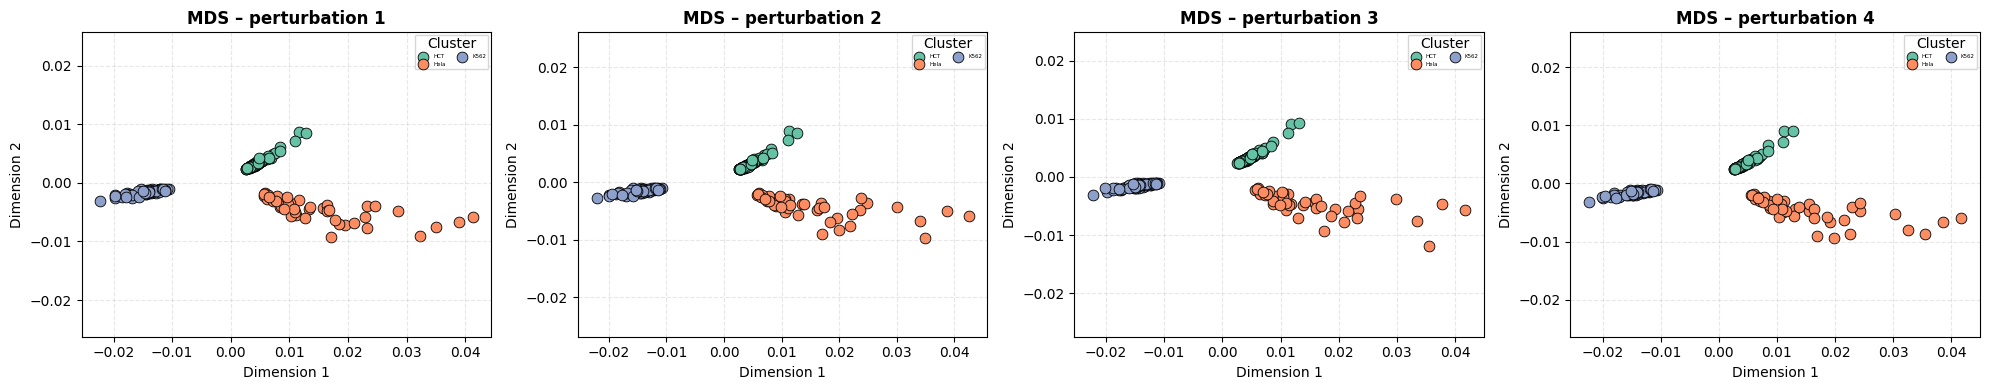

In [45]:
# PARAMETERS
n_perturbations =4
eps = 0.1

# Encode labels
labels_str = np.asarray(clusters).ravel()
le = LabelEncoder()
labels = le.fit_transform(labels_str)

# 1. OT with noise
D_ot_list = perturbed_OT_NEW(data_norm, n_perturbations=n_perturbations, eps=eps)

# 2. MDS
Y_list = compute_mds_embeddings(D_ot_list)

# 3. Plot
plot_embeddings(Y_list, labels, le.classes_, n_cols=4)


In [17]:
# 1. Generate perturbed OT distance matrices
pert = 100
D_ot_list = perturbed_OT_NEW(data_norm, n_perturbations=pert, eps=0.1, device="cuda")

#  Implementation de la methode relative a la prediction conforme

#### A noter ques les 89 premieres cellules sont celles  du cluster HCT,  de 90 à 130 sont celles de Hela et de 131 a 206 sont celles de K562 

In [18]:
def build_pair_histograms(D_ot_samples):
    """
    Pour chaque couple (i,j), collecte les n valeurs scalaires D_ot_b[i,j].
    Retourne un tableau (n_cells, n_cells, n_perturbations).
    """
    n_cells = D_ot_samples[0].shape[0]
    n_pert  = len(D_ot_samples)

    H = np.zeros((n_cells, n_cells, n_pert))
    for b, D in enumerate(D_ot_samples):
        H[:, :, b] = D

    return H  # H[i, j, :] = histogramme empirique du couple (i,j)


In [19]:
H = build_pair_histograms(D_ot_list)
H[1,2,:]

array([1.56083455e-04, 1.07380443e-04, 1.34043125e-04, 8.83823892e-05,
       1.48202200e-04, 1.03384025e-04, 1.70202795e-04, 1.65838834e-04,
       1.63885634e-04, 1.29970877e-04, 6.65567320e-05, 1.36469225e-04,
       1.42210814e-04, 1.13668768e-04, 1.03403307e-04, 1.88405856e-04,
       1.23832223e-04, 1.27369749e-04, 1.09138388e-04, 1.42480833e-04,
       1.62045556e-04, 1.61947446e-04, 1.51093243e-04, 1.31541299e-04,
       1.65833950e-04, 9.64722352e-05, 1.25884595e-04, 1.23665737e-04,
       1.27525285e-04, 1.76810633e-04, 8.87378312e-05, 1.41741922e-04,
       1.45085439e-04, 9.52455029e-05, 1.07947389e-04, 1.51378026e-04,
       1.68890658e-04, 1.61557770e-04, 9.02885007e-05, 1.23813409e-04,
       1.10710057e-04, 9.81694278e-05, 1.34306796e-04, 9.02327052e-05,
       1.51611171e-04, 1.34763331e-04, 9.36587298e-05, 1.02724428e-04,
       1.19374292e-04, 1.03282741e-04, 1.25818163e-04, 1.19905613e-04,
       1.73629873e-04, 1.41260126e-04, 1.51667084e-04, 1.13478510e-04,
      

In [20]:
# Compute OT distance matrix
C = otscomics.cost_matrix(adata.X.T.astype(np.double), 'cosine')
D_ot, errors = otscomics.OT_distance_matrix(
    data=data_norm, cost=C, eps=0.1,
    dtype=torch.double, device='cuda'
)

In [21]:
#d'apres la base les 90 cellules sont celles du clusters HCT, et les 41 suivantes sont du cluster Hla et le reste sont du cluster K562
D_ot_HCT = D_ot[:89,:89]
D_ot_Hela = D_ot[90:131,90:131]
D_ot_K562 = D_ot[132:,132:]

In [22]:
D_ot_HCT

array([[0.        , 0.00117804, 0.00096732, ..., 0.00410709, 0.00205439,
        0.00118444],
       [0.00117804, 0.        , 0.00068019, ..., 0.00600647, 0.00354011,
        0.0004499 ],
       [0.00096732, 0.00068019, 0.        , ..., 0.0055198 , 0.00310646,
        0.00050709],
       ...,
       [0.00410709, 0.00600647, 0.0055198 , ..., 0.        , 0.00228442,
        0.00651999],
       [0.00205439, 0.00354011, 0.00310646, ..., 0.00228442, 0.        ,
        0.00386248],
       [0.00118444, 0.0004499 , 0.00050709, ..., 0.00651999, 0.00386248,
        0.        ]], shape=(89, 89))

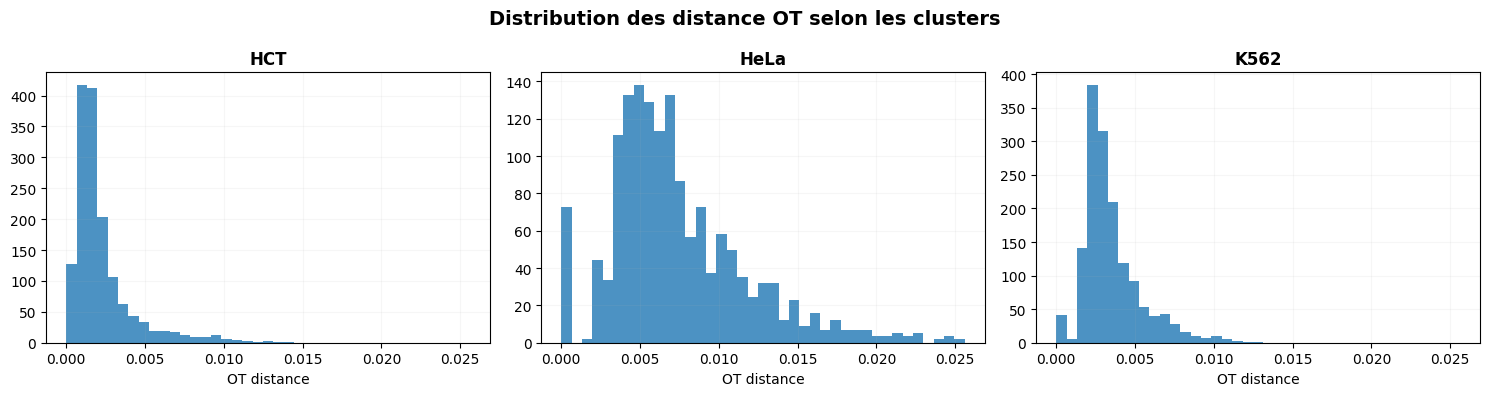

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# extraire les distances 
hct = D_ot_HCT[np.triu_indices_from(D_ot_HCT, k=0)]
hela = D_ot_Hela[np.triu_indices_from(D_ot_Hela, k=0)]
k562 = D_ot_K562[np.triu_indices_from(D_ot_K562, k=0)]


plt.figure(figsize=(15,4))

# bins communs pour comparer les distributions
bins = np.linspace(
    min(hct.min(), hela.min(), k562.min()),
    max(hct.max(), hela.max(), k562.max()),
    40
)


# HCT
plt.subplot(1,3,1)
plt.hist(hct, bins=bins, density=True, alpha=0.8)
plt.title("HCT", fontsize=12, fontweight='bold')
plt.xlabel("OT distance")
plt.grid(alpha=0.1)

# HeLa
plt.subplot(1,3,2)
plt.hist(hela, bins=bins, density=True, alpha=0.8)
plt.title("HeLa", fontsize=12, fontweight='bold')
plt.xlabel("OT distance")
plt.grid(alpha=0.1)

# K562
plt.subplot(1,3,3)
plt.hist(k562, bins=bins, density=True, alpha=0.8)
plt.title("K562", fontsize=12, fontweight='bold')
plt.xlabel("OT distance")
plt.grid(alpha=0.1)

plt.suptitle("Distribution des distance OT selon les clusters", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


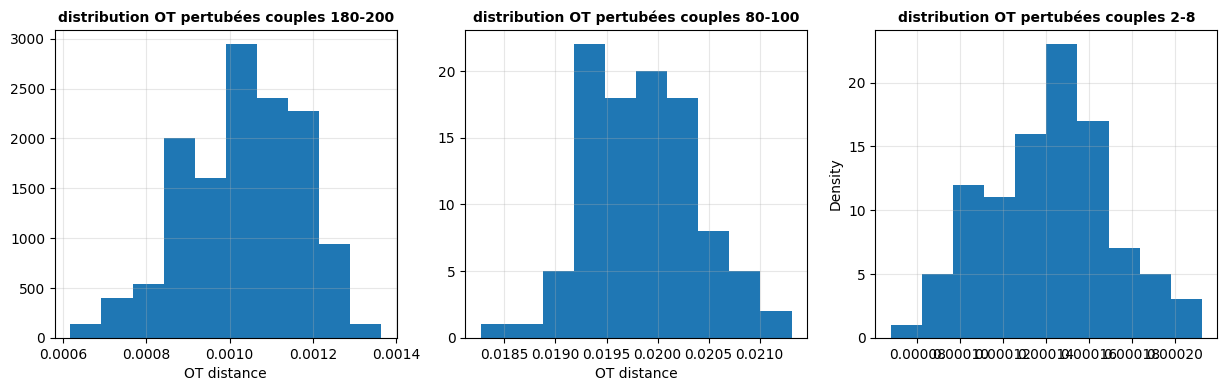

In [24]:
import matplotlib.pyplot as plt

data = build_pair_histograms(D_ot_list)

plt.figure(figsize=(15,4))



plt.subplot(1,3,1)
plt.hist(H[180,200,:], density =True)
plt.title("distribution OT pertubées couples 180-200", fontsize=10, fontweight='bold')
plt.xlabel("OT distance")
plt.grid(alpha=0.3)


plt.subplot(1,3,2)
plt.hist(H[80,100,:])
plt.title("distribution OT pertubées couples 80-100", fontsize=10, fontweight='bold')
plt.xlabel("OT distance")
plt.grid(alpha=0.3)

plt.subplot(1,3,3)
plt.hist(H[2,8,:])
plt.title("distribution OT pertubées couples 2-8", fontsize=10, fontweight='bold')
plt.ylabel("Density")
plt.grid(alpha=0.3)

plt.show()


In [25]:
min(hct.min(), hela.min(), k562.min())
max(hct.max(), hela.max(), k562.max())

np.float64(0.02560534374365142)

In [26]:
def compute_scores(H, clusters, cluster_distributions, seed=42):
    """
    Pour chaque couple (i,j), calcule W1(H_ij, H_cluster_k)
    pour CHAQUE cluster k.
    
    """
    
    rng = np.random.default_rng(seed)
    n_cells       = H.shape[0]
    n_pert        = H.shape[2]          # taille de H_ij = n_perturbations
    cluster_names = list(cluster_distributions.keys())

    H_refs_norm = {name: ref for name, ref in cluster_distributions.items()}

    scores = {name: np.zeros((n_cells, n_cells)) for name in cluster_names}

    for i in tqdm(range(n_cells), desc="Calcul scores"):
        for j in range(i + 1, n_cells):

            H_ij = H[i, j, :]

            for name, H_ref in H_refs_norm.items():
                w = wasserstein_distance(H_ij, H_ref)
                scores[name][i, j] = w
                scores[name][j, i] = w

    return scores


# Utilisation
cluster_distributions = {
    'HCT' : hct,
    'HeLa': hela,
    'K562': k562
}

scores = compute_scores(H, clusters, cluster_distributions)

Calcul scores: 100%|██████████| 206/206 [00:18<00:00, 11.34it/s]


In [27]:
scores

{'HCT': array([[0.        , 0.00198609, 0.00204121, ..., 0.0170738 , 0.01261345,
         0.01729419],
        [0.00198609, 0.        , 0.00211572, ..., 0.01466796, 0.01045988,
         0.0148484 ],
        [0.00204121, 0.00211572, 0.        , ..., 0.01511148, 0.01081783,
         0.01528328],
        ...,
        [0.0170738 , 0.01466796, 0.01511148, ..., 0.        , 0.0012058 ,
         0.0012691 ],
        [0.01261345, 0.01045988, 0.01081783, ..., 0.0012058 , 0.        ,
         0.00118437],
        [0.01729419, 0.0148484 , 0.01528328, ..., 0.0012691 , 0.00118437,
         0.        ]], shape=(206, 206)),
 'HeLa': array([[0.        , 0.00715755, 0.00720984, ..., 0.01199652, 0.0078867 ,
         0.01221525],
        [0.00715755, 0.        , 0.00728125, ..., 0.00972994, 0.0060963 ,
         0.00989854],
        [0.00720984, 0.00728125, 0.        , ..., 0.0101396 , 0.00638055,
         0.01030052],
        ...,
        [0.01199652, 0.00972994, 0.0101396 , ..., 0.        , 0.00629083,
 

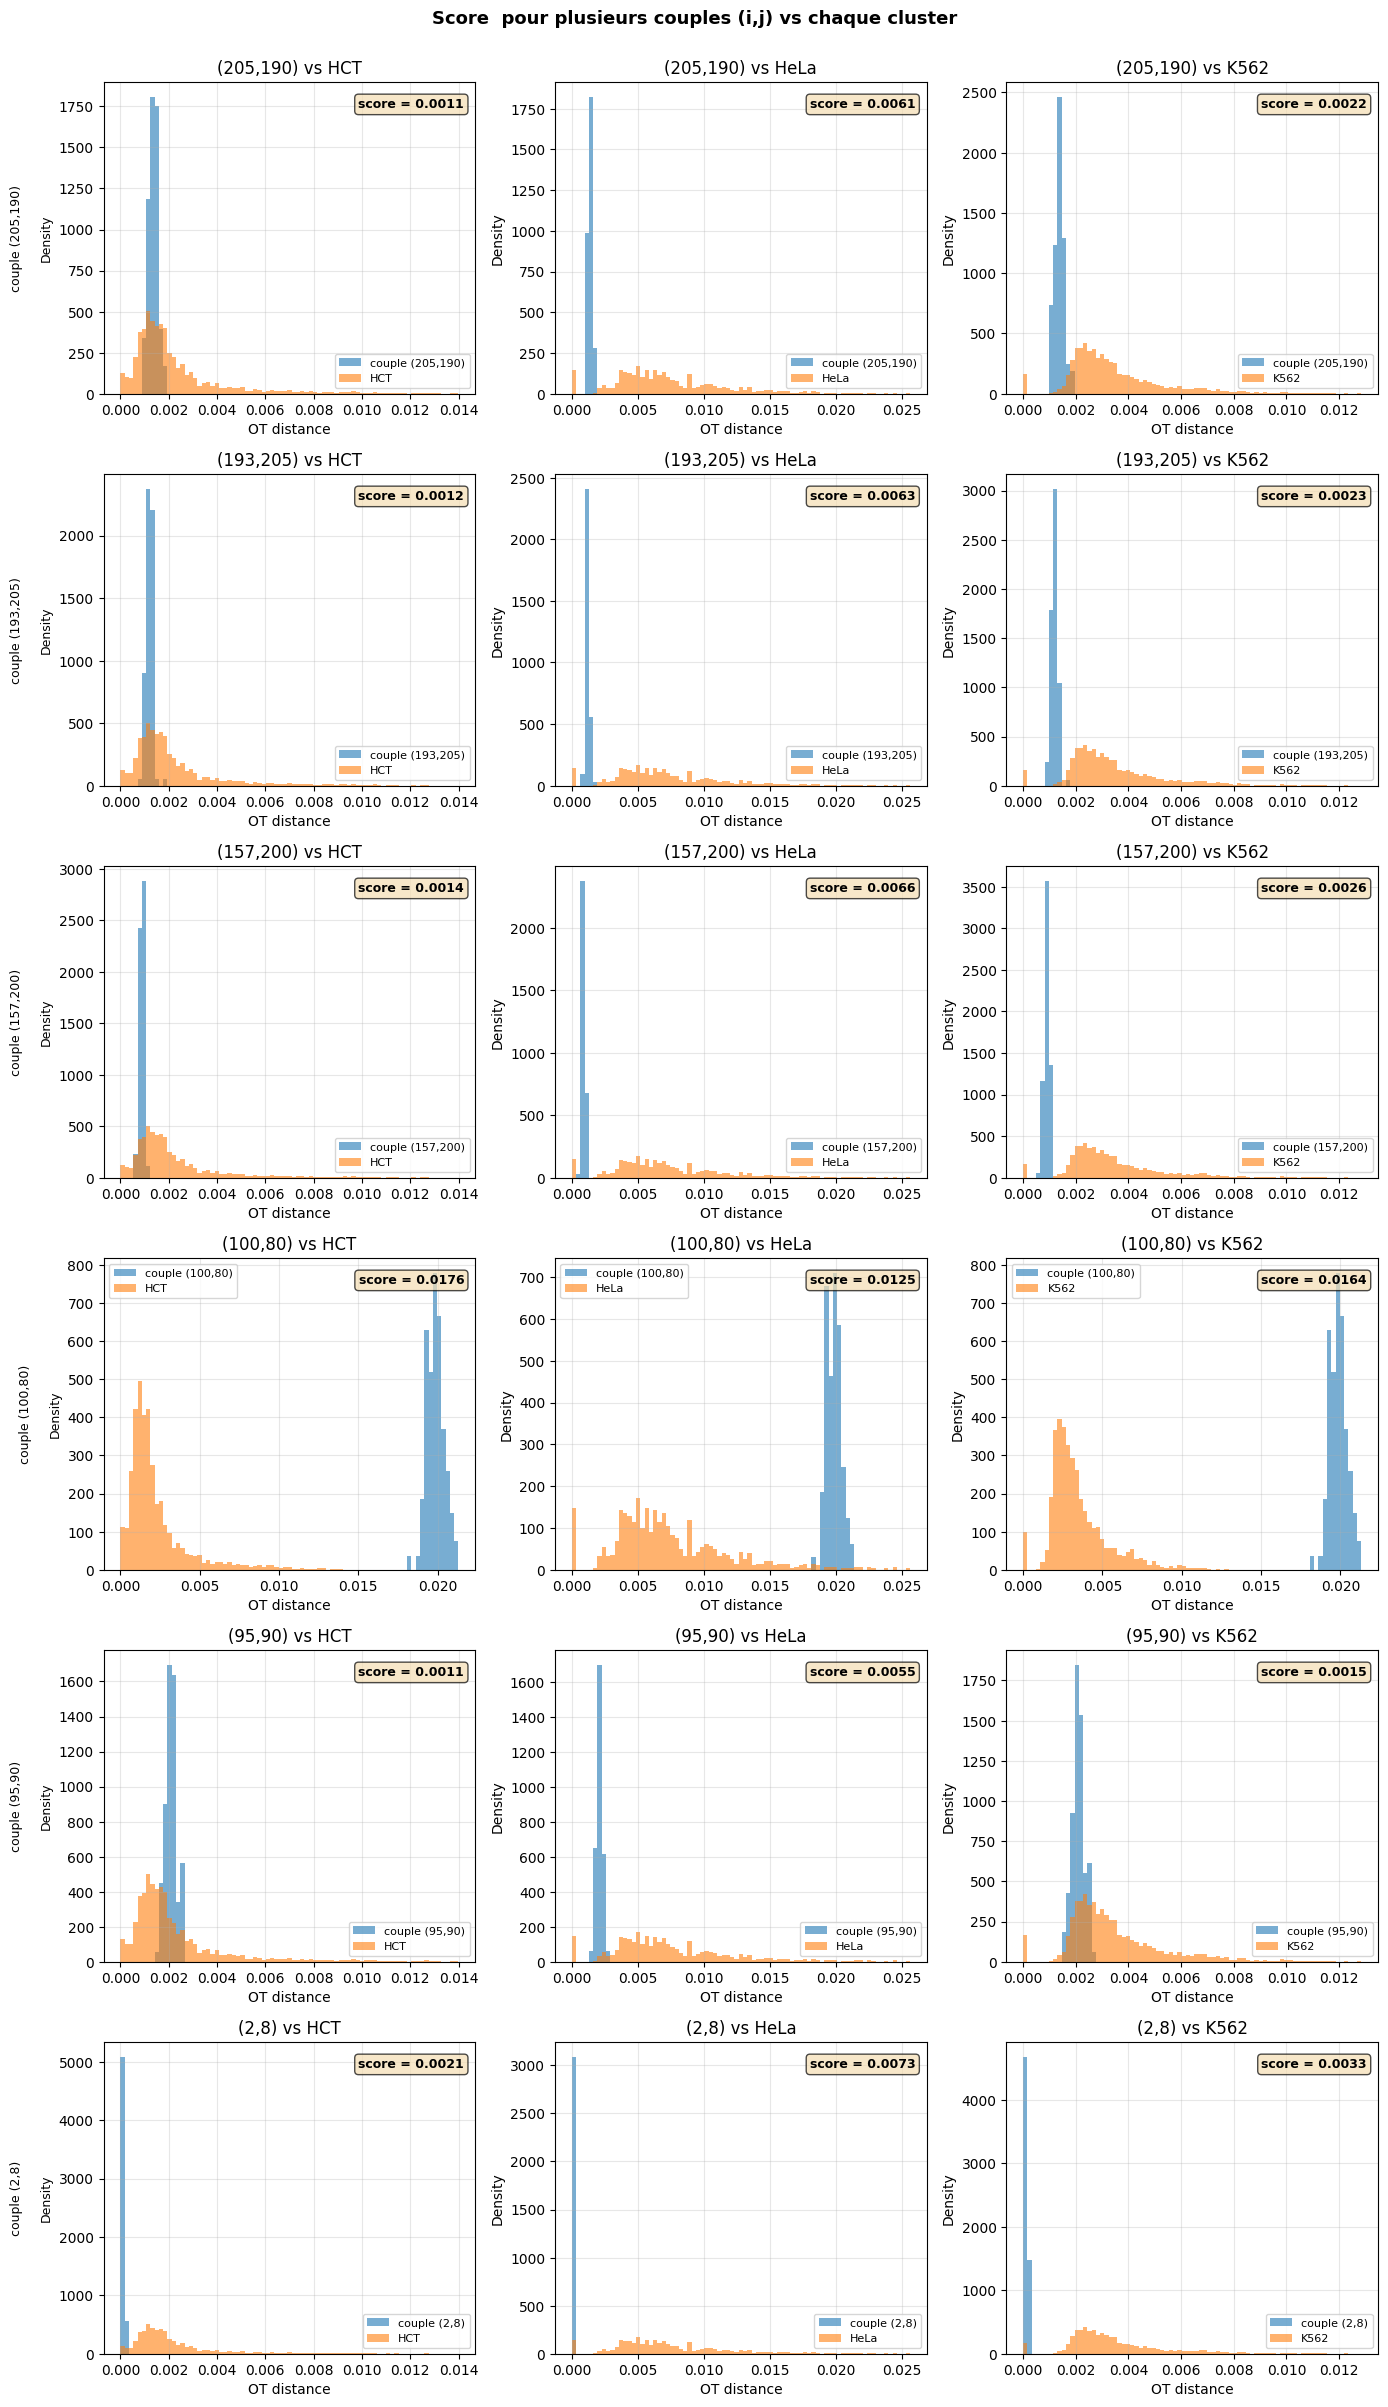

In [63]:
# Couples à afficher
couples = [(205,190), (193,205), (157,200), (100,80), (95,90), (2,8)]
fig, axes = plt.subplots(len(couples), 3, figsize=(14, 4 * len(couples)))

for row, (i, j) in enumerate(couples):

    v1 = H[i, j, :]

    score_hct  = wasserstein_distance(v1, hct)
    score_hela = wasserstein_distance(v1, hela)
    score_k562 = wasserstein_distance(v1, k562)

    for ax, (cluster_name, H_ref, w) in zip(axes[row], [
        ("HCT",  hct,  score_hct),
        ("HeLa", hela, score_hela),
        ("K562", k562, score_k562),
    ]):
        bins = np.linspace(
                min(H_ref.min(), v1.min()),
                max(H_ref.max(), v1.max()),
                80
            )
        ax.hist(v1, bins=bins,    density=True, alpha=0.6, label=f"couple ({i},{j})")
        ax.hist(H_ref, bins=bins, density=True, alpha=0.6, label=cluster_name)
        ax.set_xlabel("OT distance")
        ax.set_ylabel("Density")
        ax.set_title(f"({i},{j}) vs {cluster_name}")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        ax.text(
            0.97, 0.95,
            f"score = {w:.4f}",
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=9, fontweight='bold',
            color='black',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
        )


    # Label de la ligne à gauche
    axes[row, 0].set_ylabel(f"couple ({i},{j})\n\nDensity", fontsize=9)

plt.suptitle("Score  pour plusieurs couples (i,j) vs chaque cluster", fontsize=13, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

In [129]:
import numpy as np

def flatten_upper_triangle(matrix):
    return matrix[np.triu_indices_from(matrix, k=0)]

alpha = 0.05

quantiles = {}
for cluster_name, score_matrix in scores.items():
    upper_scores = flatten_upper_triangle(score_matrix)
    q_alpha = np.quantile(upper_scores, 1-alpha)  # quantile d'ordre 1-alpha
    quantiles[cluster_name] = q_alpha

print("Quantiles d'ordre 1-alpha pour chaque cluster :")
for c, q in quantiles.items():
    print(f"{c}: {q:.4f}")



Quantiles d'ordre 1-alpha pour chaque cluster :
HCT: 0.0333
HeLa: 0.0282
K562: 0.0321


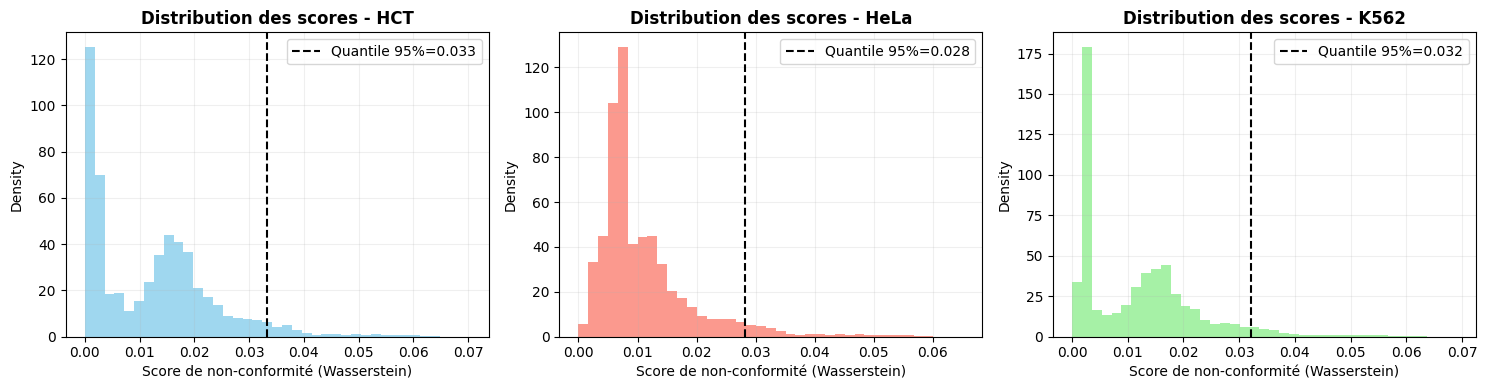

In [130]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,4))

alpha = 0.05  # niveau du quantile


cluster_names = ['HCT', 'HeLa', 'K562']
colors = ['skyblue', 'salmon', 'lightgreen']

for i, cluster_name in enumerate(cluster_names, 1):
    upper_scores = flatten_upper_triangle(scores[cluster_name])
    q_alpha = np.quantile(upper_scores, 1-alpha)  # quantile d'ordre 1-alpha
    
    bins = np.linspace(
    min(upper_scores),
    max(upper_scores),
    40
)
    
    plt.subplot(1, 3, i)
    plt.hist(upper_scores, bins=bins, density=True, color=colors[i-1], alpha=0.8)
    plt.axvline(q_alpha, color='k', linestyle='--', label=f'Quantile 95%={q_alpha:.3f}')
    plt.title(f"Distribution des scores - {cluster_name}", fontsize=12, fontweight='bold')
    plt.xlabel("Score de non-conformité (Wasserstein)")
    plt.ylabel("Density")
    plt.grid(alpha=0.2)
    plt.legend()

plt.tight_layout()
plt.show()


In [132]:
import numpy as np

# Variance + médiane des scores pour chaque cluster
for name, S in scores.items():
    vals = S[np.triu_indices_from(S, k=1)]
    print(f"{name}")
    print(f"  mean   = {vals.mean():.6f}")
    print(f"  median = {np.median(vals):.6f}")
    print(f"  std    = {vals.std():.6f}")
    print(f"  min    = {vals.min():.6f}")
    print(f"  max    = {vals.max():.6f}")
    print()

# Variance de H sur l'axe des perturbations
print(f"Std moyenne de H sur l'axe des perturbations : {H.std(axis=2).mean():.6f}")
print(f"Std max                                       : {H.std(axis=2).max():.6f}")
print(f"Std min                                       : {H.std(axis=2).min():.6f}")

HCT
  mean   = 0.012632
  median = 0.012403
  std    = 0.011195
  min    = 0.001017
  max    = 0.070256

HeLa
  mean   = 0.011162
  median = 0.007694
  std    = 0.008279
  min    = 0.002676
  max    = 0.065095

K562
  mean   = 0.012116
  median = 0.011162
  std    = 0.010513
  min    = 0.000988
  max    = 0.069016

Std moyenne de H sur l'axe des perturbations : 0.000293
Std max                                       : 0.001548
Std min                                       : 0.000000


In [64]:
# Valeur et indice du maximum
idx_max = np.argmax(hct)
val_max = hct[idx_max]

print(f"Valeur max cluster hct : {val_max:.6f}")
print(f"Indice     : {idx_max}")

# Retrouver le couple (i,j) correspondant dans la matrice
rows, cols = np.triu_indices_from(D_ot_HCT, k=0)
i, j = rows[idx_max], cols[idx_max]

print(f"Couple     : ({i}, {j})")
print(f"Vérif      : D_ot_HCT[{i},{j}] = {D_ot_HCT[i,j]:.6f}")

Valeur max cluster hct : 0.013996
Indice     : 3560
Couple     : (59, 79)
Vérif      : D_ot_HCT[59,79] = 0.013996
